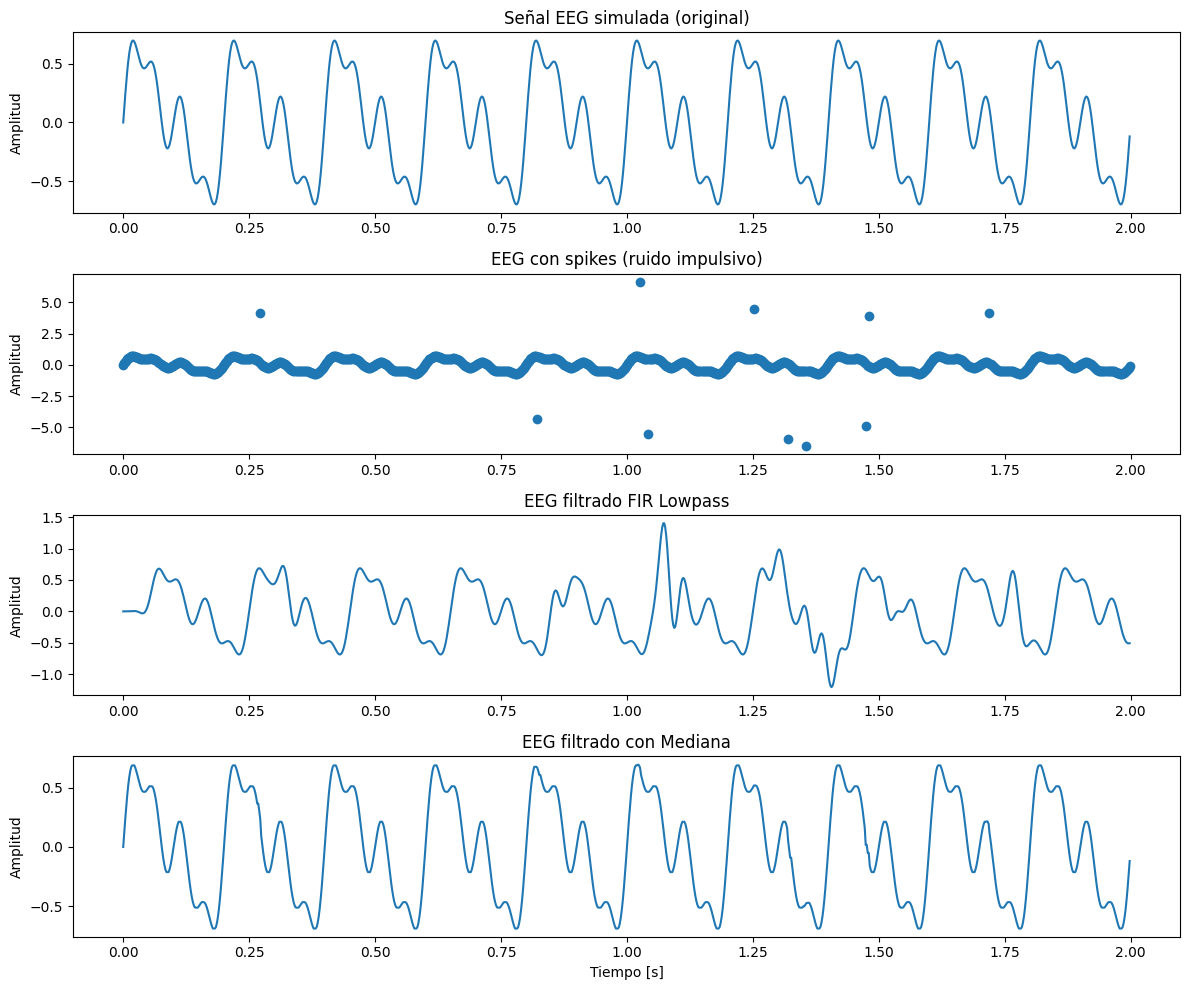

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

# --- Parámetros ---
fs = 500  # Frecuencia de muestreo EEG
t = np.arange(0, 2, 1/fs)  # 2 segundos
# Señal EEG simulada: combinación de senos (0.5-30 Hz típico)
eeg = 0.5*np.sin(2*np.pi*5*t) + 0.3*np.sin(2*np.pi*10*t) + 0.2*np.sin(2*np.pi*20*t)

# --- Insertar 10 spikes aleatorios ---
np.random.seed(42)  # reproducible
spike_indices = np.random.choice(len(t), 10, replace=False)
eeg_with_spikes = eeg.copy()
eeg_with_spikes[spike_indices] += np.random.choice([4, -5, 6, -6], size=10)  # amplitud grande

# --- Filtro FIR lowpass ---
numtaps = 51
cutoff = 30  # Hz
fir_coeff = firwin(numtaps, cutoff, fs=fs)
filtered_fir = lfilter(fir_coeff, 1.0, eeg_with_spikes)

# --- Filtro mediana ---
filtered_med = medfilt(eeg_with_spikes, kernel_size=5)

# --- Graficar ---
plt.figure(figsize=(12,10))

plt.subplot(4,1,1)
plt.plot(t, eeg)
plt.title("Señal EEG simulada (original)")
plt.ylabel("Amplitud")

plt.subplot(4,1,2)
plt.plot(t, eeg_with_spikes, marker='o', linestyle='None')
plt.title("EEG con spikes (ruido impulsivo)")
plt.ylabel("Amplitud")

plt.subplot(4,1,3)
plt.plot(t, filtered_fir)
plt.title("EEG filtrado FIR Lowpass")
plt.ylabel("Amplitud")

plt.subplot(4,1,4)
plt.plot(t, filtered_med)
plt.title("EEG filtrado con Mediana")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

plt.tight_layout()
plt.show()